# BERT 전이학습으로 문장 분류하기

전이학습은 대규모 말뭉치에서 언어 구조를 익힌 BERT를 작은 downstream 데이터에 맞게 재사용하는 방법이다. 문장 분류에서는 `[CLS]` 문맥 벡터 위에 새 분류 head를 붙여 클래스별 로짓을 만들고, 정답 label과의 손실을 통해 학습 가능한 가중치를 갱신한다.

이 노트북은 한국어 감성 문장 16개를 Train 12개와 Validation 4개로 미리 분리한다. 작은 예시는 성능 경쟁용 데이터가 아니라 입력 → 변환 → 출력 → 사용처를 짧게 확인하는 수업용 경로이다.


## 1. 학습 데이터와 검증 데이터의 경계

Train은 optimizer가 가중치를 갱신하는 데이터이고, Validation은 학습 중 일반화 상태를 비교하는 데이터이다. 같은 문장이 양쪽에 들어가거나 Validation loss로 `backward()`를 호출하면 모델 선택 기준이 오염된다. 최종 Test가 따로 있다면 임계값과 epoch까지 Validation에서 결정한 뒤 Test는 마지막 한 번만 사용한다.

여기서는 외부 NSMC 다운로드 없이 긍정과 부정 문장을 직접 넣어 흐름을 재현한다. 실제 NSMC 실습으로 확장할 때도 먼저 분리하고 그다음 토큰화를 적용하는 원칙은 같다.


In [1]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

torch.manual_seed(42)

train_samples = [
    ("배우들의 연기가 정말 자연스럽고 몰입감이 좋았다", 1),
    ("마지막 장면이 오래 기억에 남는 훌륭한 영화다", 1),
    ("음악과 영상이 잘 어울려 다시 보고 싶다", 1),
    ("전개가 탄탄하고 인물의 감정이 설득력 있다", 1),
    ("짧지만 따뜻한 여운을 주는 작품이다", 1),
    ("기대보다 훨씬 재미있고 웃음이 끊이지 않았다", 1),
    ("이야기가 지루하고 결말도 이해하기 어려웠다", 0),
    ("배우의 연기가 어색해서 집중하기 힘들었다", 0),
    ("전개가 너무 느리고 같은 장면이 반복된다", 0),
    ("음향이 불편하고 화면도 지나치게 어두웠다", 0),
    ("기대했지만 내용이 평범해서 실망했다", 0),
    ("등장인물의 행동에 개연성이 전혀 없었다", 0),
]
validation_samples = [
    ("섬세한 연출 덕분에 끝까지 집중해서 보았다", 1),
    ("주제와 연기가 조화를 이룬 인상적인 작품이다", 1),
    ("농담이 억지스럽고 이야기도 산만했다", 0),
    ("결말이 갑작스럽고 감정선도 납득하기 어렵다", 0),
]

# Validation 문장은 optimizer가 보는 Train 문장과 겹치지 않아야 한다.
train_texts = {text for text, _ in train_samples}
validation_texts = {text for text, _ in validation_samples}
print("train/validation sizes:", len(train_samples), len(validation_samples))
print("text overlap:", train_texts & validation_texts)


train/validation sizes: 12 4
text overlap: set()


## 2. 토큰화와 DataLoader

`klue/bert-base` 토크나이저는 한국어 문장을 WordPiece ID로 바꾼다. `padding="max_length"`는 모든 예제를 같은 길이로 만들고, `truncation=True`는 설정한 길이를 넘는 토큰을 자른다. 짧은 예제의 `max_length=32`는 메모리와 시간을 줄이기 위한 수업용 선택이다.

Dataset의 한 항목은 `input_ids`, `attention_mask`, `token_type_ids`, `labels`를 담는다. DataLoader가 네 항목을 쌓으면 각 입력은 `(B, T)`, labels는 `(B,)`가 된다.


In [2]:
MODEL_ID = "klue/bert-base"
MAX_LENGTH = 32
BATCH_SIZE = 4

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)


class SentimentDataset(Dataset):
    def __init__(self, samples):
        # 문장 목록은 BERT 입력으로, 정수 label은 CrossEntropyLoss의 정답으로 사용한다.
        texts = [text for text, _ in samples]
        self.labels = torch.tensor([label for _, label in samples])
        self.encodings = tokenizer(
            texts,
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        # 같은 index의 input_ids·mask·label을 한 학습 항목으로 묶는다.
        item = {key: value[index] for key, value in self.encodings.items()}
        item["labels"] = self.labels[index]
        return item


train_loader = DataLoader(
    SentimentDataset(train_samples), batch_size=BATCH_SIZE, shuffle=True
)
validation_loader = DataLoader(
    SentimentDataset(validation_samples), batch_size=BATCH_SIZE, shuffle=False
)

sample_batch = next(iter(train_loader))
for key, value in sample_batch.items():
    print(f"{key:16s} shape={tuple(value.shape)}")


input_ids        shape=(4, 32)
token_type_ids   shape=(4, 32)
attention_mask   shape=(4, 32)
labels           shape=(4,)


## 3. 분류 head와 짧은 head-only 전이학습

`AutoModelForSequenceClassification`은 BERT Encoder 위에 dropout과 선형 분류 head를 붙인다. `num_labels=2`이므로 출력 로짓은 `(B, 2)`이다. 이 head는 체크포인트에 없던 새 파라미터이므로 처음에는 임의 초기화되고 downstream 정답으로 학습해야 한다.

전체 BERT를 한 번에 갱신하면 CPU 수업 환경에서 시간이 길어질 수 있다. 여기서는 Encoder 전체를 고정하고 분류 head만 5 epoch 학습하는 **head-only 전이학습**을 사용한다. 이는 BERT 전체를 미세조정하는 경로가 아니라 사전학습 표현 위에서 새 head의 학습 변화와 데이터 경계를 짧게 관찰하는 경로이다.

전체 미세조정에서는 Encoder의 `requires_grad`를 켜고 head보다 작은 learning rate를 사용한다. 작은 데이터에서는 epoch를 늘리는 것보다 Validation 변화와 과적합을 함께 관찰하는 것이 중요하다.


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# classifier MISSING은 새 분류 head를 지금부터 학습한다는 정상 안내이다.
# MLM·NSP 계층 UNEXPECTED는 문장 분류에 사용하지 않는 출력층을 제외했다는 뜻이다.

# 사전 학습된 KLUE(문장 분류)모델을 얻어옴

# num_labels=2 -> 문장이 분류될 정답의 수 (긍정/부정, 2개)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID, num_labels=2
).to(device)

# 사전학습 BERT Encoder를 고정하고 새 classifier만 학습한다.
for parameter in model.base_model.parameters():
    parameter.requires_grad = False

# BASE Model을 제외한 나머지 파라미터는 학습 활성화
trainable_parameters = [
    parameter for parameter in model.parameters() if parameter.requires_grad
]

# 지정된 파라미터만 최적화
optimizer = AdamW(trainable_parameters, lr=1e-3)
criterion = nn.CrossEntropyLoss()

trainable_count = sum(parameter.numel() for parameter in trainable_parameters)
total_count = sum(parameter.numel() for parameter in model.parameters())
print("device:", device)
print(f"trainable parameters: {trainable_count:,} / {total_count:,}")


def evaluate(data_loader):
    model.eval()
    loss_sum = 0.0
    correct = 0
    example_count = 0

    # Validation에서는 gradient와 가중치 갱신을 사용하지 않는다.
    with torch.no_grad():
        for batch in data_loader:
            # 입력과 label을 모델과 같은 장치로 옮긴다.
            batch = {key: value.to(device) for key, value in batch.items()}
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                token_type_ids=batch.get("token_type_ids"),
            )
            # 로짓의 가장 큰 열이 예측 클래스이며, loss는 정답 label과 비교한 오차이다.
            loss = criterion(outputs.logits, batch["labels"])
            predictions = outputs.logits.argmax(dim=-1)
            batch_size = batch["labels"].size(0)
            loss_sum += loss.item() * batch_size
            correct += (predictions == batch["labels"]).sum().item()
            example_count += batch_size

    return loss_sum / example_count, correct / example_count


initial_validation_loss, initial_validation_accuracy = evaluate(
    validation_loader
)
print(f"initial validation loss: {initial_validation_loss:.4f}")
print(f"initial validation accuracy: {initial_validation_accuracy:.4f}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: klue/bert-base
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


device: cpu
trainable parameters: 1,538 / 110,618,882
initial validation loss: 0.7754
initial validation accuracy: 0.2500


## 4. Train에서만 갱신하고 Validation에서 평가하기

학습 배치에서는 `zero_grad()`로 이전 gradient를 지우고, 로짓과 label로 CrossEntropyLoss를 계산한 뒤 `backward()`와 `step()`을 호출한다. label은 정수 클래스 번호이므로 shape `(B,)`를 유지한다.

Validation에서는 `model.eval()`로 dropout을 끄고 `torch.no_grad()`로 gradient 기록을 막는다. 이 경로에는 `optimizer.step()`이 없다. 매 epoch 뒤 같은 Validation 함수로 loss와 accuracy를 기록해 학습 전 기준선과 비교한다.

작은 내장 데이터의 정확도는 모델 성능 근거가 아니라 두 데이터 경계와 API 흐름이 올바르게 연결됐는지 확인하는 관찰값이다. Validation loss가 줄지 않거나 accuracy가 0.5에 머물러도 성능을 과장하지 않고, 예제 수가 적고 Encoder를 고정했다는 조건을 함께 해석해야 한다.


In [4]:
EPOCHS = 5
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    # 전체 모델을 train으로 바꾼 뒤 고정 Encoder의 dropout만 다시 끈다.
    model.base_model.eval()
    train_loss_sum = 0.0
    train_example_count = 0

    for batch in train_loader:
        batch = {key: value.to(device) for key, value in batch.items()}
        # 이전 배치의 기울기를 지우고 현재 배치의 오차만 계산한다.
        optimizer.zero_grad()
        outputs = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            token_type_ids=batch.get("token_type_ids"),
        )
        logits = outputs.logits  # (B, 2)
        loss = criterion(logits, batch["labels"])
        # backward로 기울기를 계산하고, clipping 뒤 optimizer가 classifier를 갱신한다.
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_parameters, max_norm=1.0)
        optimizer.step()

        batch_size = batch["labels"].size(0)
        train_loss_sum += loss.item() * batch_size
        train_example_count += batch_size

    train_loss = train_loss_sum / train_example_count
    validation_loss, validation_accuracy = evaluate(validation_loader)
    history.append(
        (epoch, train_loss, validation_loss, validation_accuracy)
    )
    print(
        f"epoch={epoch}, train_loss={train_loss:.4f}, "
        f"validation_loss={validation_loss:.4f}, "
        f"validation_accuracy={validation_accuracy:.4f}"
    )

print("last logits shape:", tuple(logits.shape))


epoch=1, train_loss=0.6225, validation_loss=0.6421, validation_accuracy=0.7500
epoch=2, train_loss=0.5587, validation_loss=0.5614, validation_accuracy=0.7500
epoch=3, train_loss=0.4477, validation_loss=0.4723, validation_accuracy=0.7500
epoch=4, train_loss=0.4303, validation_loss=0.4050, validation_accuracy=1.0000
epoch=5, train_loss=0.3471, validation_loss=0.3353, validation_accuracy=1.0000
last logits shape: (4, 2)


### 학습 전후 Validation 비교

학습 전 랜덤 분류 head의 기준값과 마지막 epoch 값을 같은 Validation 함수로 비교한다. 변화 방향을 출력하되 예제 네 개의 결과를 일반 성능으로 해석하지 않는다.


In [5]:
# 마지막 epoch 지표를 학습 전 Validation 지표와 같은 기준으로 비교한다.
final_epoch, final_train_loss, final_validation_loss, final_validation_accuracy = (
    history[-1]
)
loss_change = final_validation_loss - initial_validation_loss
accuracy_change = final_validation_accuracy - initial_validation_accuracy

print(
    f"validation loss: {initial_validation_loss:.4f} "
    f"-> {final_validation_loss:.4f} ({loss_change:+.4f})"
)
print(
    f"validation accuracy: {initial_validation_accuracy:.4f} "
    f"-> {final_validation_accuracy:.4f} ({accuracy_change:+.4f})"
)

if final_validation_loss < initial_validation_loss:
    print("관찰: 작은 예제에서 Validation loss가 감소했다.")
else:
    print("관찰: Validation loss가 감소하지 않았다.")
print("해석 경계: 데이터가 매우 작고 BERT Encoder를 고정한 수업용 결과이다.")


validation loss: 0.7754 -> 0.3353 (-0.4401)
validation accuracy: 0.2500 -> 1.0000 (+0.7500)
관찰: 작은 예제에서 Validation loss가 감소했다.
해석 경계: 데이터가 매우 작고 BERT Encoder를 고정한 수업용 결과이다.


## 5. 새 문장 추론과 해석 경계

추론에서는 학습 때와 같은 토크나이저, 길이 제한, 특수 토큰 규칙을 사용한다. softmax는 두 로짓을 합이 1인 확률처럼 바꾸지만, 작은 예제로 head만 5 epoch 학습한 값은 신뢰도나 배포 기준으로 사용할 수 없다.

실무에서는 클래스 비율, 데이터 중복, 문장 출처, 적절한 metric을 먼저 점검하고 Train에서 학습한 여러 후보를 Validation에서 선택한다. Hub 업로드는 모델 품질과 데이터 공개 범위를 별도로 검토한 뒤 수행해야 하므로 이 교안에서는 제외한다.


In [6]:
new_texts = [
    "배우들의 섬세한 연기가 마음에 남았다",
    "이야기가 산만해서 끝까지 보기 힘들었다",
]
new_inputs = tokenizer(
    new_texts,
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt",
).to(device)

# 새 문장은 정답 없이 추론하며 softmax가 부정·긍정 상대 점수로 변환한다.
model.eval()
with torch.no_grad():
    new_logits = model(**new_inputs).logits
    new_probabilities = torch.softmax(new_logits, dim=-1)

label_names = {0: "부정", 1: "긍정"}
for text, probabilities in zip(new_texts, new_probabilities.cpu()):
    predicted_id = int(probabilities.argmax())
    print(text)
    print(label_names[predicted_id], probabilities.tolist())


배우들의 섬세한 연기가 마음에 남았다
긍정 [0.3152241110801697, 0.6847759485244751]
이야기가 산만해서 끝까지 보기 힘들었다
부정 [0.6410453915596008, 0.3589545786380768]


## BERT 전이학습 전체 흐름 정리

위쪽 한 줄은 문장부터 `optimizer.step()`까지의 학습 순서이다. 아래 상자는 Train에서만 loss·backward·가중치 갱신을 수행하고 Validation에서는 예측과 지표만 계산한다는 데이터 경계를 요약한다.

이 교안에서는 BERT Encoder를 고정했으므로 그림의 `가중치 갱신`은 새로 추가한 분류 head에만 해당한다.

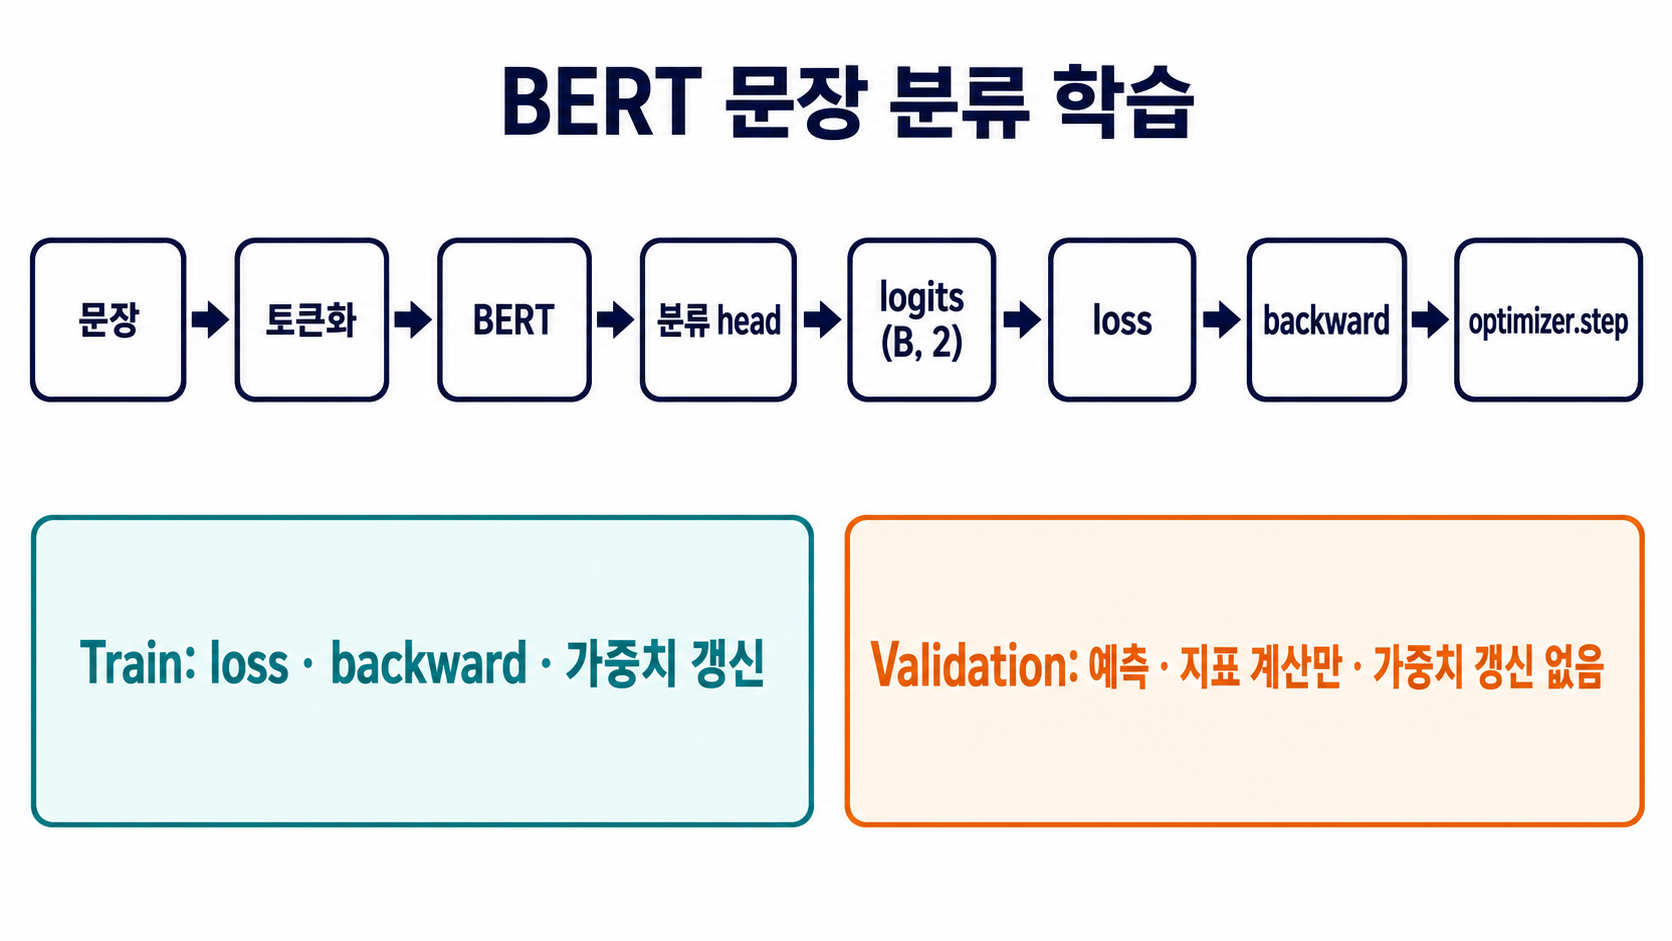
